## NUTS3 Sites 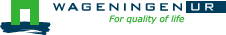
------------------------------
In this notebook, the use of QGIS and Eurostat NUTS3' shape file will be used, together with geopandas centroid function, to be able to derive a representable point for each region. for which to simulate Miscanthus for. This centroid is particular useful for querying the AgERA5 API when wanting to run WOFOST.

%pip install geopandas

In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
# reading selected NUTS3 regions
selection = pd.read_excel('nuts3site_selection.xlsx', sheet_name="nuts3_constraints")
wanted = set(selection['nuts3'])

# reading the NUTS3 shapefile (Eurostat GISCO NUTS 2016)
gdf = gpd.read_file("NUTS_RG_01M_2016_3035/NUTS_RG_01M_2016_3035.shp")

# NUTS3 filter 
nuts3 = gdf[(gdf['LEVL_CODE'] == 3) & (gdf['NUTS_ID'].isin(wanted))].copy()

# calculate selected NUTS3 centroids
cent = nuts3.geometry.centroid

# express centroids as lon/lat for AgERA 5 API (using EPSG:4326)
cent = cent.to_crs(4326)
nuts3["lon"], nuts3["lat"] = cent.x, cent.y

# attaching lon/lat to selection
out = selection.merge(nuts3[["NUTS_ID", "lon", "lat"]], left_on="nuts3", right_on="NUTS_ID", how="left")

missing = sorted(wanted - set(nuts3["NUTS_ID"]))
print(f"{len(missing)} codes not matched:", missing)

# create dataframe to work with in the next steps
sites = (out.dropna(subset=["lat", "lon"])
            .drop(columns=["NUTS_ID"])
            .reset_index(drop=True))
sites.to_csv("nuts3_centroid.csv", index=False)
sites.head()

85 codes not matched: ['AL111', 'BA111', 'ELZZZ', 'FI1D4', 'FI1D6', 'FR213', 'FR431', 'FR432', 'FR434', 'FR515', 'FR522', 'FR532', 'FR621', 'FR626', 'FR631', 'FR713', 'FR714', 'FR717', 'FR718', 'FR722', 'FR812', 'FR813', 'FR814', 'FR821', 'FR822', 'FR823', 'FR824', 'FR826', 'FR831', 'FR832', 'IE011', 'IE013', 'IE023', 'IE024', 'IE025', 'LT001', 'LT002', 'LT004', 'LT005', 'LT006', 'LT008', 'LT009', 'LT00A', 'MD111', 'ME111', 'NL122', 'NL338', 'PL116', 'PL117', 'PL129', 'PL12B', 'PL12D', 'PL12E', 'PL323', 'PL343', 'PL344', 'PL345', 'UA112', 'UA113', 'UA114', 'UA117', 'UA118', 'UA11B', 'UA11E', 'UA11L', 'UA11O', 'UKM21', 'UKM23', 'UKM24', 'UKM26', 'UKM27', 'UKM28', 'UKM31', 'UKM32', 'UKM33', 'UKM34', 'UKM35', 'UKM36', 'UKM37', 'UKM38', 'UKN01', 'UKN02', 'UKN03', 'UKN04', 'UKN05']


,nuts3,constraints,lon,lat
0,AL013,gdd,20.243061,42.195249
1,AT111,drainage,16.483019,47.512822
2,AT121,frost_damage,14.997992,48.053067
3,AT122,gdd,15.902765,47.797763
4,AT124,frost_damage,15.317263,48.642773
